box plot

Saved: D:\BIOvisdata\SSGAT\Groundtruth\boxplot_grid_all_topics_3D.png


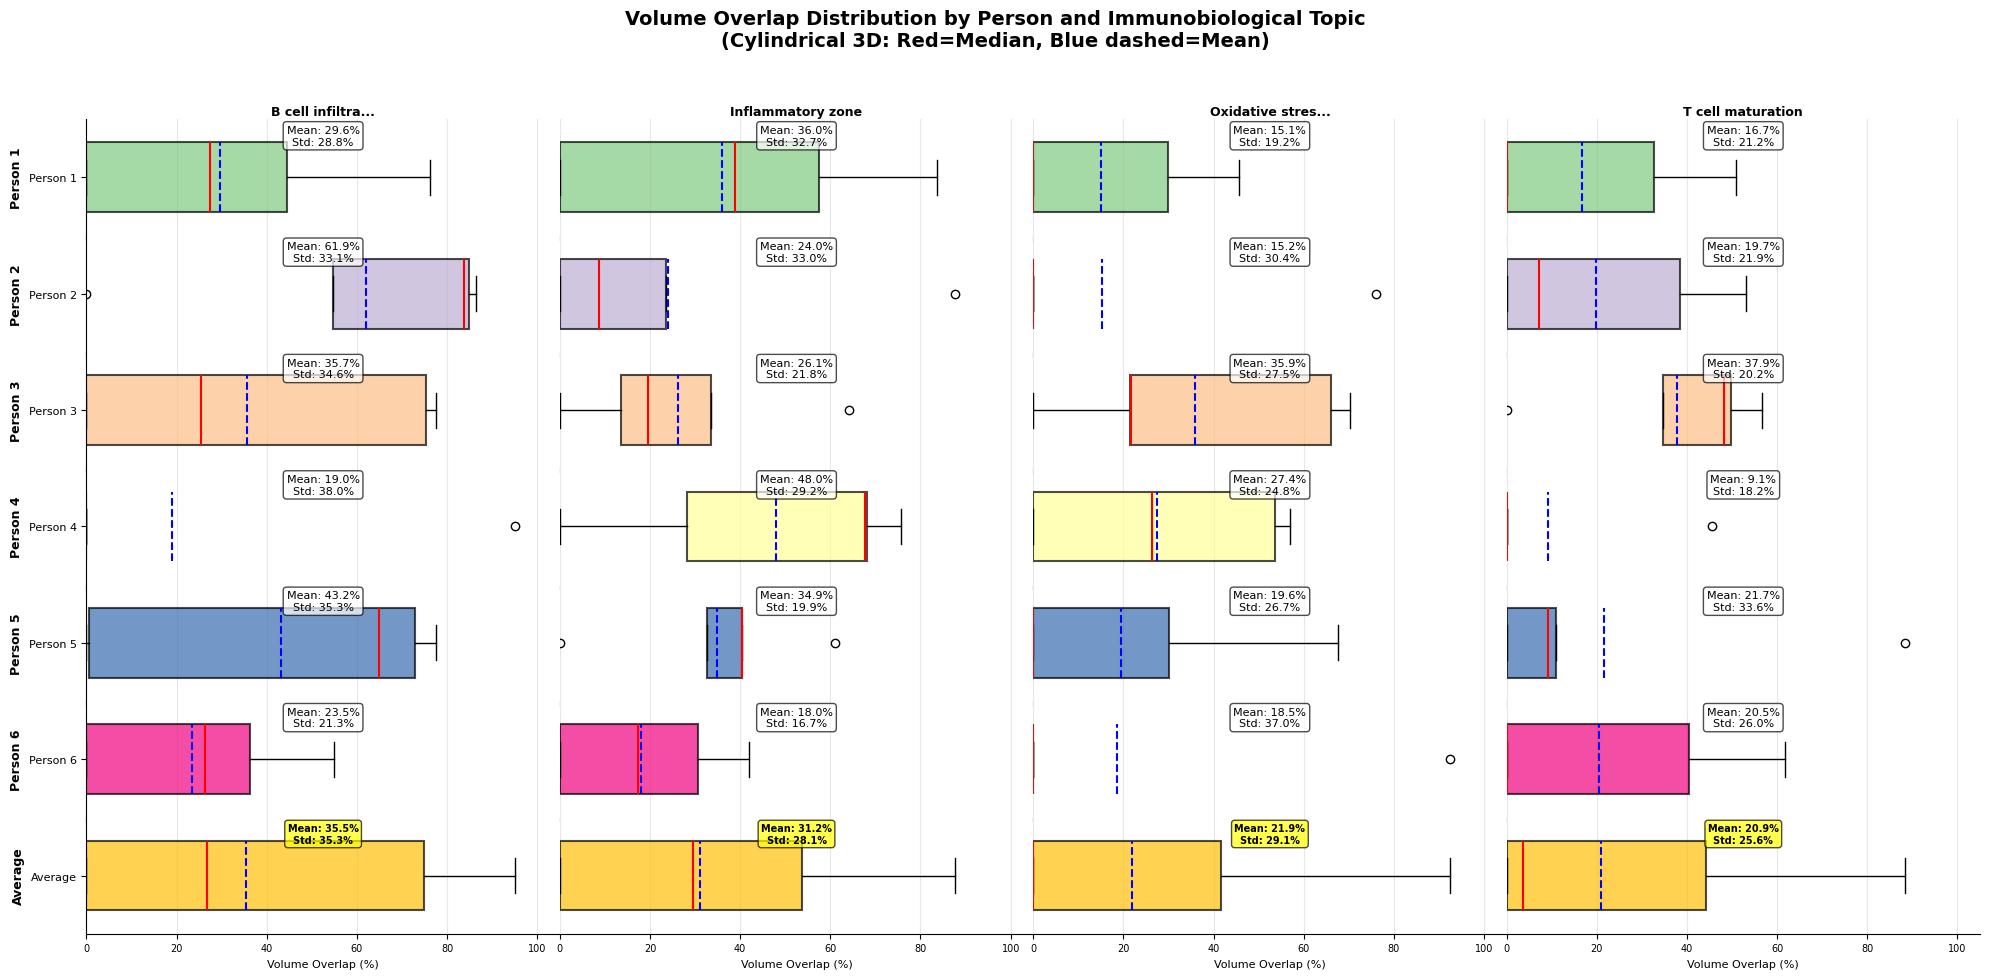

Saved: D:\BIOvisdata\SSGAT\Groundtruth\heatmap_volume_overlap_3D.png


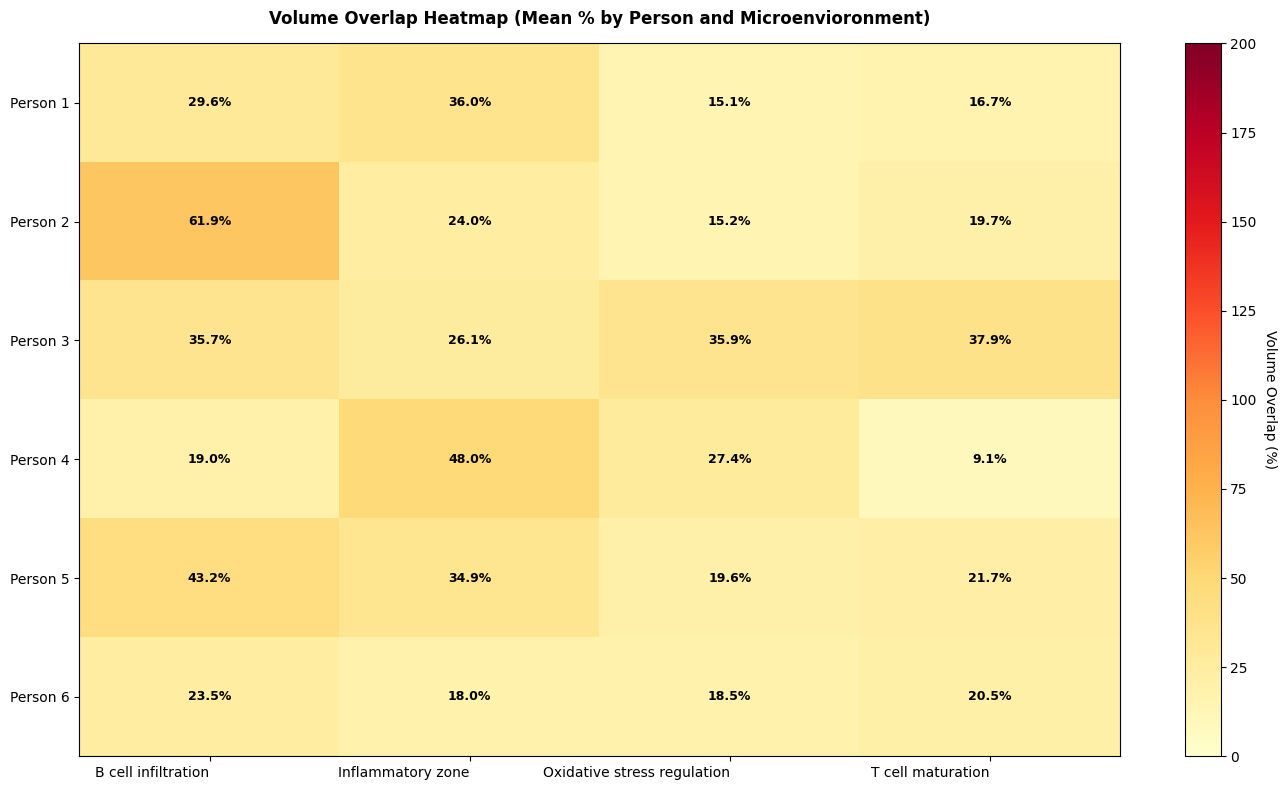

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import math
import warnings
warnings.filterwarnings('ignore')

base_dir = Path(r"D:\BIOvisdata\SSGAT\Groundtruth")
csv_files = [
    'roi_coordinates_B-cell_infiltration.csv',
    'roi_coordinates_Inflammatory_zone.csv',
    'roi_coordinates_Oxidative_stress_regulation.csv',
    'roi_coordinates_T-cell_maturation.csv'
]

cylinder_radius, cylinder_height = 400, 100
z_tolerance = 50

def circle_overlap(c1, c2, r):
    d = math.sqrt((c2[0]-c1[0])**2 + (c2[1]-c1[1])**2)
    if d >= 2*r: return 0.0
    if d == 0: return 100.0
    try:
        area = 2*r**2*math.acos(d/(2*r)) - (d/2)*math.sqrt(4*r**2-d**2)
        return min(100.0, (area/(math.pi*r**2))*100)
    except: return 100.0 if d < 2*r else 0.0

def z_overlap(z1, z2, h, z_tol):
    dz = abs(z1 - z2)
    if dz <= z_tol:
        return 100.0
    excess_diff = dz - z_tol
    overlap_percent = max(0.0, 100.0 - (excess_diff / h) * 100)
    return overlap_percent

def volume_overlap(c1, z1, c2, z2, r, h, z_tol):
    xy_overlap = circle_overlap(c1, c2, r) / 100.0
    z_overlap_pct = z_overlap(z1, z2, h, z_tol) / 100.0
    return min(100.0, xy_overlap * z_overlap_pct * 100.0)

def calc_overlaps(gat_data, person_data, r, h, z_tol):
    if len(gat_data) == 0 or len(person_data) == 0: return []
    gat = gat_data[['x', 'y', 'z']].values
    person = person_data[['x', 'y', 'z']].values
    rows, cols = linear_sum_assignment(cdist(gat, person))
    return [volume_overlap((gat[i][0], gat[i][1]), gat[i][2], (person[j][0], person[j][1]), person[j][2], r, h, z_tol)
            for i, j in zip(rows, cols)]

# Process each CSV file
results = {}
all_overlaps = {f'Person {i}': [] for i in range(1, 7)}

for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        continue
    
    df = pd.read_csv(csv_path)
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    
    gat_data = df[df.iloc[:, 0] == 'GAT'].copy()
    gat_data = gat_data.sort_values(by='ROI_ID').reset_index(drop=True)
    
    results[sheet_name] = {}
    
    for person_num in range(1, 7):
        person_name = f'Person {person_num}'
        person_data = df[df.iloc[:, 0] == person_name].copy()
        person_data = person_data.sort_values(by='ROI_ID').reset_index(drop=True)
        
        if len(person_data) == 0:
            continue
        
        overlaps = calc_overlaps(gat_data, person_data, cylinder_radius, cylinder_height, z_tolerance)
        
        if len(overlaps) > 0:
            results[sheet_name][person_name] = {
                'overlaps': overlaps,
                'mean': np.mean(overlaps),
                'std': np.std(overlaps),
                'min': np.min(overlaps),
                'max': np.max(overlaps)
            }
            all_overlaps[person_name].extend(overlaps)


person_names = [f'Person {i}' for i in range(1, 7)]
person_colors = ['#7fc97f', '#beaed4', '#fdc086', '#ffff99', '#386cb0', '#f0027f']
topics_list = list(results.keys()) if len(results) > 0 else []

fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(7, 4, hspace=0.0, wspace=0.0)

for col_idx, sheet_name in enumerate(topics_list):
    all_topic_overlaps = []
    
    for row_idx, person_name in enumerate(person_names):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        
        if person_name in results[sheet_name]:
            overlaps = results[sheet_name][person_name]['overlaps']
            if len(overlaps) > 0:
                all_topic_overlaps.extend(overlaps)
                bp = ax.boxplot([overlaps], tick_labels=[person_name], patch_artist=True,
                               vert=False, showmeans=True, meanline=True,
                               boxprops=dict(linewidth=1.5),
                               medianprops=dict(linewidth=1.5, color='red'),
                               meanprops=dict(linewidth=1.5, linestyle='--', color='blue'),
                               whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), widths=0.6)
                bp['boxes'][0].set_facecolor(person_colors[row_idx])
                bp['boxes'][0].set_alpha(0.7)
                bp['boxes'][0].set_edgecolor('black')
                bp['boxes'][0].set_linewidth(1.5)
                
                stats = results[sheet_name][person_name]
                stats_text = f"Mean: {stats['mean']:.1f}%\nStd: {stats['std']:.1f}%"
                ax.text(0.5, 0.95, stats_text, transform=ax.transAxes,
                       ha='center', va='top', fontsize=8,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
            else:
                bp = ax.boxplot([[]], tick_labels=[person_name], patch_artist=True, vert=False, widths=0.6)
                bp['boxes'][0].set_facecolor('lightgray')
                bp['boxes'][0].set_alpha(0.3)
        else:
            bp = ax.boxplot([[]], tick_labels=[person_name], patch_artist=True, vert=False, widths=0.6)
            bp['boxes'][0].set_facecolor('lightgray')
            bp['boxes'][0].set_alpha(0.3)
        
        ax.set_xlim(0, 105)
        ax.grid(True, alpha=0.3, axis='x')
        ax.tick_params(axis='y', labelsize=8)
        ax.tick_params(axis='x', labelsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if row_idx < 6:
            ax.spines['bottom'].set_visible(False)
        if col_idx > 0:
            ax.spines['left'].set_visible(False)
        
        if col_idx == 0:
            ax.set_ylabel(person_name, fontsize=9, fontweight='bold')
        else:
            ax.set_ylabel('')
            ax.set_yticks([])
        
        if row_idx == 6:
            ax.set_xlabel('Volume Overlap (%)', fontsize=8)
        else:
            ax.set_xticklabels([])
        
        if row_idx == 0:
            short_name = sheet_name.replace('_', ' ').replace('-', ' ')
            if len(short_name) > 18:
                short_name = short_name[:15] + '...'
            ax.set_title(short_name, fontsize=9, fontweight='bold', pad=3)
    
    ax_avg = fig.add_subplot(gs[6, col_idx])
    if len(all_topic_overlaps) > 0:
        bp_avg = ax_avg.boxplot([all_topic_overlaps], tick_labels=['Average'], patch_artist=True,
                               vert=False, showmeans=True, meanline=True,
                               boxprops=dict(linewidth=1.5),
                               medianprops=dict(linewidth=1.5, color='red'),
                               meanprops=dict(linewidth=1.5, linestyle='--', color='blue'),
                               whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), widths=0.6)
        bp_avg['boxes'][0].set_facecolor('#FFC107')
        bp_avg['boxes'][0].set_alpha(0.7)
        bp_avg['boxes'][0].set_edgecolor('black')
        bp_avg['boxes'][0].set_linewidth(1.5)
        
        stats_text = f"Mean: {np.mean(all_topic_overlaps):.1f}%\nStd: {np.std(all_topic_overlaps):.1f}%"
        ax_avg.text(0.5, 0.95, stats_text, transform=ax_avg.transAxes,
                   ha='center', va='top', fontsize=7, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    else:
        bp_avg = ax_avg.boxplot([[]], tick_labels=['Average'], patch_artist=True, vert=False, widths=0.6)
        bp_avg['boxes'][0].set_facecolor('lightgray')
        bp_avg['boxes'][0].set_alpha(0.3)
    
    ax_avg.set_xlim(0, 105)
    ax_avg.grid(True, alpha=0.3, axis='x')
    ax_avg.tick_params(axis='y', labelsize=8)
    ax_avg.tick_params(axis='x', labelsize=7)
    ax_avg.set_xlabel('Volume Overlap (%)', fontsize=8)
    ax_avg.spines['top'].set_visible(False)
    ax_avg.spines['right'].set_visible(False)
    if col_idx > 0:
        ax_avg.spines['left'].set_visible(False)
    
    if col_idx == 0:
        ax_avg.set_ylabel('Average', fontsize=9, fontweight='bold')
    else:
        ax_avg.set_ylabel('')
        ax_avg.set_yticks([])

fig.suptitle('Volume Overlap Distribution by Person and Immunobiological Topic\n(Cylindrical 3D: Red=Median, Blue dashed=Mean)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
output_path = base_dir / 'boxplot_grid_all_topics_3D.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Saved: {output_path}")
plt.show()

# Create heatmap
fig2, ax2 = plt.subplots(figsize=(14, 8))
heatmap_data = []
heatmap_rows = []
heatmap_cols = topics_list

for person_name in person_names:
    row_data = []
    for sheet_name in topics_list:
        if person_name in results[sheet_name] and len(results[sheet_name][person_name]['overlaps']) > 0:
            row_data.append(results[sheet_name][person_name]['mean'])
        else:
            row_data.append(np.nan)
    if any(not np.isnan(x) for x in row_data):
        heatmap_data.append(row_data)
        heatmap_rows.append(person_name)

if len(heatmap_data) > 0:
    heatmap_array = np.array(heatmap_data)
    im = ax2.imshow(heatmap_array, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
    
    ax2.set_xticks(np.arange(len(heatmap_cols)))
    ax2.set_yticks(np.arange(len(heatmap_rows)))
    ax2.set_xticklabels([name.replace('_', ' ').replace('-', ' ') for name in heatmap_cols], rotation=45, ha='right')
    ax2.set_yticklabels(heatmap_rows)
    
    for i in range(len(heatmap_rows)):
        for j in range(len(heatmap_cols)):
            if not np.isnan(heatmap_array[i, j]):
                text = ax2.text(j, i, f'{heatmap_array[i, j]:.1f}%',
                              ha="center", va="center", color="black", fontsize=9, fontweight='bold')
    
    ax2.set_title('Volume Overlap Heatmap (Mean % by Person and Microenvioronment)', fontsize=12, fontweight='bold', pad=14)
    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('Volume Overlap (%)', rotation=0, labelpad=15)
    
    plt.tight_layout()
    heatmap_path = base_dir / 'heatmap_volume_overlap_3D.png'
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {heatmap_path}")
    plt.show()


BArchart

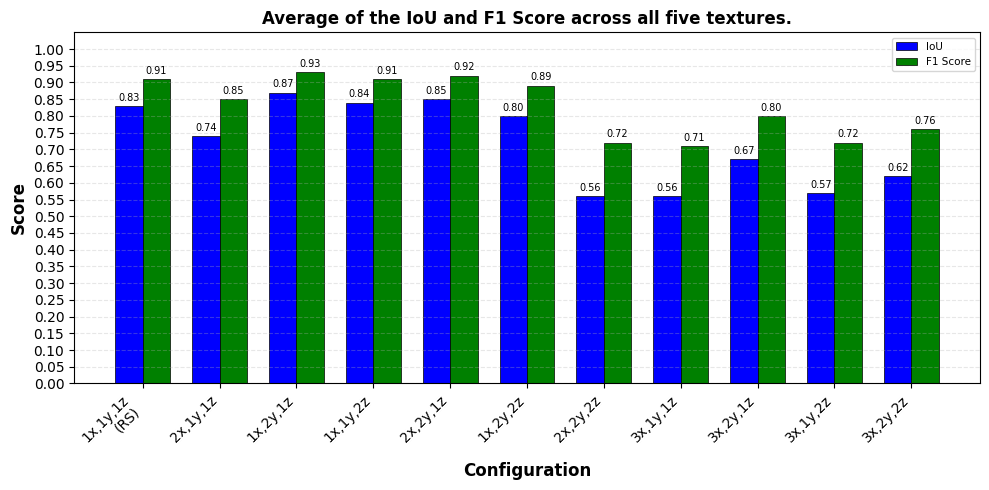

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data from Table 1
configurations = [
    '1x,1y,1z\n(RS)',
    '2x,1y,1z',
    '1x,2y,1z',
    '1x,1y,2z',
    '2x,2y,1z',
    '1x,2y,2z',
    '2x,2y,2z',
    '3x,1y,1z',
    '3x,2y,1z',
    '3x,1y,2z',
    '3x,2y,2z'
]

IoU_scores = [
    0.83, 0.74, 0.87, 0.84, 0.85, 0.80, 0.56,
    0.56, 0.67, 0.57, 0.62]

f1_scores = [
    0.91, 0.85, 0.93, 0.91, 0.92, 0.89, 0.72,
    0.71, 0.80, 0.72, 0.76]

# Create bar chart with grouped bars
x = np.arange(len(configurations)) * 0.7  # Closer x steps for compact figure
width = 0.25  # Thinner bars

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, IoU_scores, width, label='IoU', 
               color='blue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', 
               color='green', edgecolor='black', linewidth=0.5)

# Customize the chart
ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Average of the IoU and F1 Score across all five textures.', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(configurations, rotation=45, ha='right', fontsize=10)
ax.set_yticks(np.arange(0.0, 1.05, 0.05))
ax.set_yticklabels([f'{i:.2f}' for i in np.arange(0.0, 1.05, 0.05)], fontsize=10)
ax.set_ylim(0.0, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=7.5)

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=7)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

======================================================================
FINAL RESULTS TABLE
======================================================================

Scale Name    Scale                  GT File  Matches  Model Points  GT Points Precision Recall F1 Score IoU
  original 1x,1x,1x groundtruth_original.npy       88           100        100    0.8800 0.8800   0.8800   0.7857
    2x1y1z 2x,1x,1x   groundtruth_2x1y1z.npy       75           100        100    0.7500 0.7500   0.7500   0.6000
    1x2y1z 1x,2x,1x   groundtruth_1x2y1z.npy       90           100        100    0.9000 0.9000   0.9000   0.8182
    1x1y2z 1x,1x,2x   groundtruth_1x1y2z.npy       91           100        100    0.9100 0.9100   0.9100   0.8349
    2x2y1z 2x,2x,1x   groundtruth_2x2y1z.npy       91           100        100    0.9100 0.9100   0.9100   0.8349
    1x2y2z 1x,2x,2x   groundtruth_1x2y2z.npy       90           100        100    0.9000 0.9000   0.9000   0.8182
    2x2y2z 2x,2x,2x   groundtruth_2x2y2z.npy       92           100        100    0.9200 0.9200   0.9200   0.8519
    3x1y1z 3x,1x,1x   groundtruth_3x1y1z.npy       65           100        100    0.6500 0.6500   0.6500   0.4815
    3x2y1z 3x,2x,1x   groundtruth_3x2y1z.npy       77           100        100    0.7700 0.7700   0.7700   0.6260
    3x1y2z 3x,1x,2x   groundtruth_3x1y2z.npy       63           100        100    0.6300 0.6300   0.6300   0.4599
    3x2y2z 3x,2x,2x   groundtruth_3x2y2z.npy       70           100        100    0.7000 0.7000   0.7000   0.5385

✓ Results saved to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale/IoU_results.csv

======================================================================
EXPERIMENT COMPLETE!
======================================================================


======================================================================
FINAL RESULTS TABLE
======================================================================

Scale Name    Scale                  GT File  Matches  Model Points  GT Points Precision Recall F1 Score IoU
  original 1x,1x,1x groundtruth_original.npy       88           100        100    0.8800 0.8800   0.8800   0.7857
    2x1y1z 2x,1x,1x   groundtruth_2x1y1z.npy       75           100        100    0.7500 0.7500   0.7500   0.6000
    1x2y1z 1x,2x,1x   groundtruth_1x2y1z.npy       90           100        100    0.9000 0.9000   0.9000   0.8182
    1x1y2z 1x,1x,2x   groundtruth_1x1y2z.npy       91           100        100    0.9100 0.9100   0.9100   0.8349
    2x2y1z 2x,2x,1x   groundtruth_2x2y1z.npy       91           100        100    0.9100 0.9100   0.9100   0.8349
    1x2y2z 1x,2x,2x   groundtruth_1x2y2z.npy       90           100        100    0.9000 0.9000   0.9000   0.8182
    2x2y2z 2x,2x,2x   groundtruth_2x2y2z.npy       92           100        100    0.9200 0.9200   0.9200   0.8519
    3x1y1z 3x,1x,1x   groundtruth_3x1y1z.npy       65           100        100    0.6500 0.6500   0.6500   0.4815
    3x2y1z 3x,2x,1x   groundtruth_3x2y1z.npy       77           100        100    0.7700 0.7700   0.7700   0.6260
    3x1y2z 3x,1x,2x   groundtruth_3x1y2z.npy       63           100        100    0.6300 0.6300   0.6300   0.4599
    3x2y2z 3x,2x,2x   groundtruth_3x2y2z.npy       70           100        100    0.7000 0.7000   0.7000   0.5385

✓ Results saved to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale/IoU_results.csv

======================================================================
EXPERIMENT COMPLETE!
======================================================================
